# Gem Data Cleaning and Normalization

This notebook standardizes and normalizes the gem dataset attributes, focusing on:
- Gem type names
- Clarity grades
- Color information
- Cut/shape values 
- Treatment labels
- Certification status

In [29]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import re

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 1000)

# Set random seed for reproducibility
np.random.seed(42)

# Configure plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

## 1. Load and Examine Data

First, let's load the dataset and examine its contents to identify data quality issues.

In [30]:
# Read the dataset
df = pd.read_csv('data/seller-e/master.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumns in dataset:")
print(df.dtypes)
print("\nSample of raw data:")
display(df.head())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Display unique values in categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("\nUnique values in categorical columns:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())

Dataset Shape: (19229, 12)

Columns in dataset:
Gem Type                               object
Variety                                object
Carat Weight (ct)                     float64
Cut/Shape                              object
Colour                                 object
Clarity                                object
Treatments                             object
Asking Price (LKR)                    float64
Final Selling Price (if available)    float64
Dimensions (LxWxH, mm)                 object
Certification Status                   object
Date                                   object
dtype: object

Sample of raw data:


,Gem Type,Variety,Carat Weight (ct),Cut/Shape,Colour,Clarity,Treatments,Asking Price (LKR),Final Selling Price (if available),"Dimensions (LxWxH, mm)",Certification Status,Date
0,Sapphire,Blue,0.77,Mixed Brilliant Oval,Blue,Eye Clean,Heat Treated,675675.0,NaN,7.0 x 4.9 x 2.81,Certified by Natural Sapphire Company,2025-09-06
1,Sapphire,Blue,1.00,Mixed Brilliant Cushion,Blue,Very Slightly Included,Heat Treated,325000.0,NaN,7.42 x 4.8 x 3.18,Certified by Natural Sapphire Company,2025-09-06
2,Sapphire,Purple,1.75,Mixed Brilliant Pear,Purple,Very Very Slightly Included,No Enhancement,325000.0,NaN,8.95 x 5.77 x 4.33,Certified by Natural Sapphire Company,2025-09-06
3,Sapphire,Blue,3.04,Asscher Asscher - Octagon,Blue,Eye Clean,Heat Treated,5038800.0,NaN,8.09 x 7.96 x 5.03,Certified by Natural Sapphire Company,2025-09-06
4,Sapphire,White,2.02,Step Cut Fancy,White,Eye Clean,No Enhancement,984750.0,NaN,8.37 x 9.55 x 3.31,Certified by Natural Sapphire Company,2025-09-06



Missing values:
Gem Type                                  0
Variety                                   0
Carat Weight (ct)                         0
Cut/Shape                                 0
Colour                                    0
Clarity                                   0
Treatments                                0
Asking Price (LKR)                        0
Final Selling Price (if available)    19229
Dimensions (LxWxH, mm)                    0
Certification Status                      0
Date                                      0
dtype: int64

Unique values in categorical columns:

Gem Type:
['Sapphire' 'Zircon' 'Moonstone' 'Cobalt Spinel' 'Rhodolite Garnet'
 'Aquamarine' 'Alexandrite' 'Chrysoberyl' 'Beryl' 'Amethyst'
 'Almandine Garnet' 'Spinel' 'Garnet' 'Rubellite Tourmaline' 'Tourmaline'
 'Peridot' 'Spessartite Garnet' 'Topaz' 'Citrine' 'Smokey Quartz'
 'Kornerupine' 'Hessonite Garnet' 'Sinhalite' 'Rutilated Quartz'
 'Andesine' 'Scapolite' 'Apatite' 'Fluorite' 'Ruby']

Vari

## 2. Clean Gem Type Names

Standardize gem type names by:
1. Converting to title case
2. Removing extra whitespace
3. Mapping variations to standard names
4. Correcting misspellings

Unique gem types after standardization:
Gem Type
Sapphire                15638
Spinel                    888
Moonstone                 447
Garnet                    437
Zircon                    401
Citrine                   284
Chrysoberyl               259
Amethyst                  165
Topaz                     156
Rhodolite Garnet          129
Tourmaline                105
Aquamarine                 78
Hessonite Garnet           69
Alexandrite                48
Cobalt Spinel              30
Ruby                       29
Almandine Garnet           21
Beryl                      11
Kornerupine                 8
Rubellite Tourmaline        7
Spessartite Garnet          5
Sinhalite                   3
Rutilated Quartz            3
Peridot                     2
Andesine                    2
Smokey Quartz               1
Scapolite                   1
Apatite                     1
Fluorite                    1
Name: count, dtype: int64


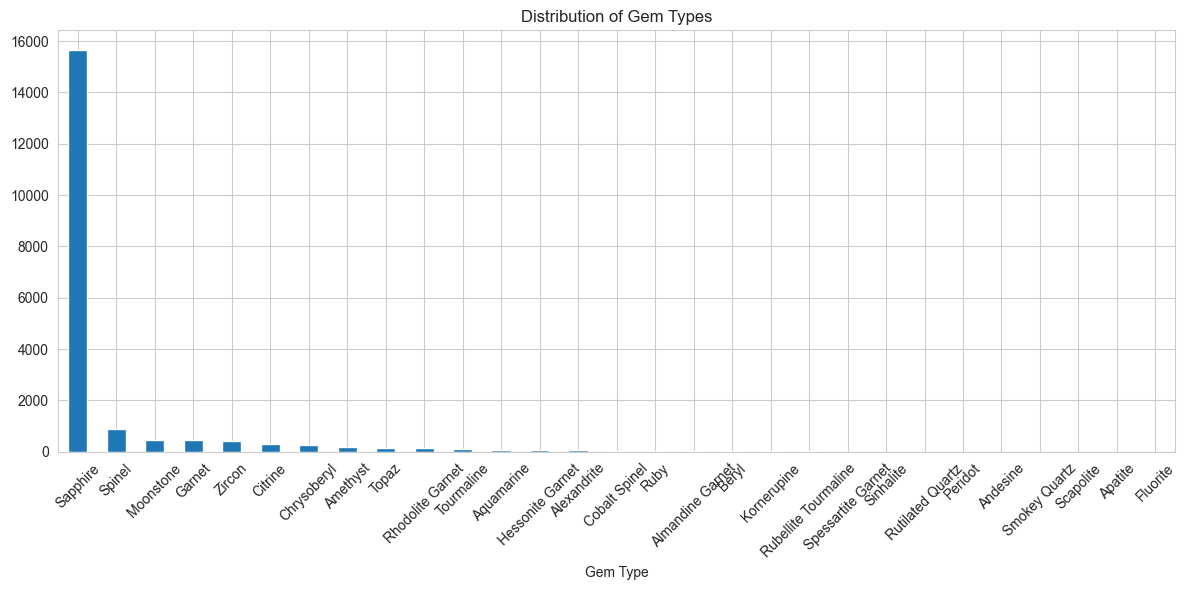

In [31]:
def standardize_gem_type(gem_type):
    """
    Standardize gem type names to a consistent format
    """
    if pd.isna(gem_type):
        return "Unknown"
    
    # Convert to string and clean
    gem_type = str(gem_type).strip().title()
    
    # Mapping of variations to standard names
    gem_type_mapping = {
        'Sapphire Blue': 'Blue Sapphire',
        'Blue Saphire': 'Blue Sapphire',
        'Yellow Saphire': 'Yellow Sapphire',
        'Pink Saphire': 'Pink Sapphire',
        'White Saphire': 'White Sapphire',
        'Natural Sapphire': 'Sapphire',
        'Natural Ruby': 'Ruby',
    }
    
    return gem_type_mapping.get(gem_type, gem_type)

# Apply standardization
df['Gem Type'] = df['Gem Type'].apply(standardize_gem_type)

# Display results
print("Unique gem types after standardization:")
print(df['Gem Type'].value_counts())

# Visualize distribution
plt.figure(figsize=(12, 6))
df['Gem Type'].value_counts().plot(kind='bar')
plt.title('Distribution of Gem Types')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Standardize Clarity Grades

Map various clarity descriptions to standard grades:
- VVS (Very Very Slightly Included)
- VS (Very Slightly Included)
- SI (Slightly Included)
- I (Included)
- Eye Clean

Unique clarity grades after standardization:
Clarity
VS           11119
Eye Clean     4452
SI            1880
VVS           1721
I               57
Name: count, dtype: int64


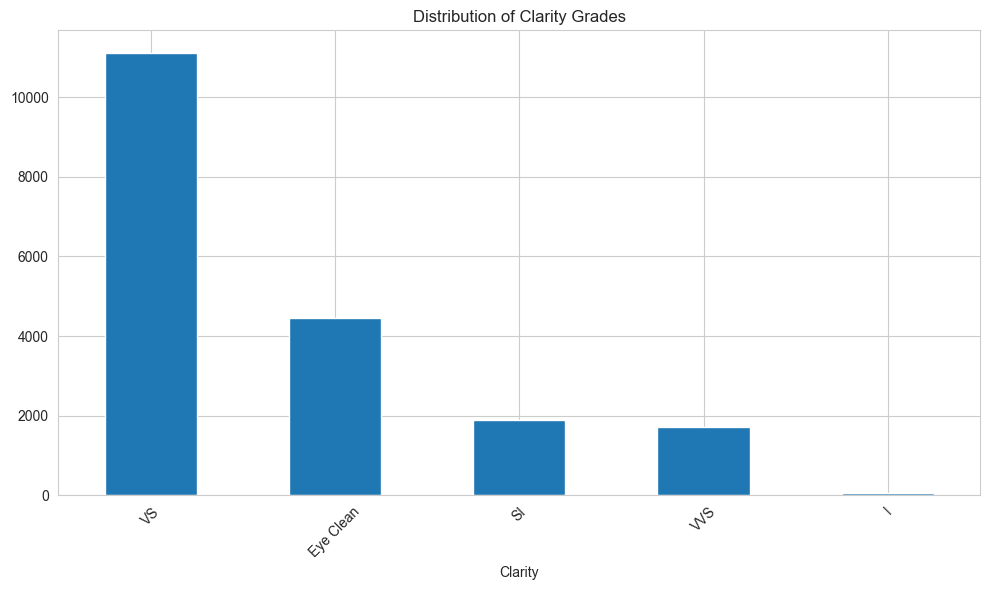

In [32]:
def standardize_clarity(clarity):
    """
    Standardize clarity grades to a consistent format
    """
    if pd.isna(clarity):
        return "Unknown"
    
    clarity = str(clarity).strip().upper()
    
    # Mapping of variations to standard grades
    clarity_mapping = {
        # VVS variations
        'VVS': 'VVS',
        'VERY VERY SLIGHTLY INCLUDED': 'VVS',
        'VVS1': 'VVS',
        'VVS2': 'VVS',
        
        # VS variations
        'VS': 'VS',
        'VERY SLIGHTLY INCLUDED': 'VS',
        'VS1': 'VS',
        'VS2': 'VS',
        
        # SI variations
        'SI': 'SI',
        'SLIGHTLY INCLUDED': 'SI',
        'SI1': 'SI',
        'SI2': 'SI',
        
        # Eye Clean variations
        'EYE CLEAN': 'Eye Clean',
        'CLEAN': 'Eye Clean',
        'EC': 'Eye Clean',
        
        # Included variations
        'I': 'I',
        'INCLUDED': 'I',
        'I1': 'I',
        'I2': 'I',
        'I3': 'I'
    }
    
    # Try to match with standard grades
    for pattern, grade in clarity_mapping.items():
        if pattern in clarity:
            return grade
    
    return clarity

# Apply standardization
df['Clarity'] = df['Clarity'].apply(standardize_clarity)

# Display results
print("Unique clarity grades after standardization:")
print(df['Clarity'].value_counts())

# Visualize distribution
plt.figure(figsize=(10, 6))
df['Clarity'].value_counts().plot(kind='bar')
plt.title('Distribution of Clarity Grades')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Normalize Color Information

Clean and standardize color descriptions:
1. Separate hue from tone/saturation where possible
2. Map similar colors to standard categories
3. Handle special color descriptions (e.g., fancy colors)

Unique colors after standardization:

Colour column:
Colour
Blue                                 6916
Yellow                               1777
Pink                                 1561
Purple                               1352
Pinkish Purple                        646
                                     ... 
Brownish Pink                           1
Watermelon                              1
Greyish Brown                           1
Golden                                  1
Yellowish Green To Purplish Brown       1
Name: count, Length: 66, dtype: int64


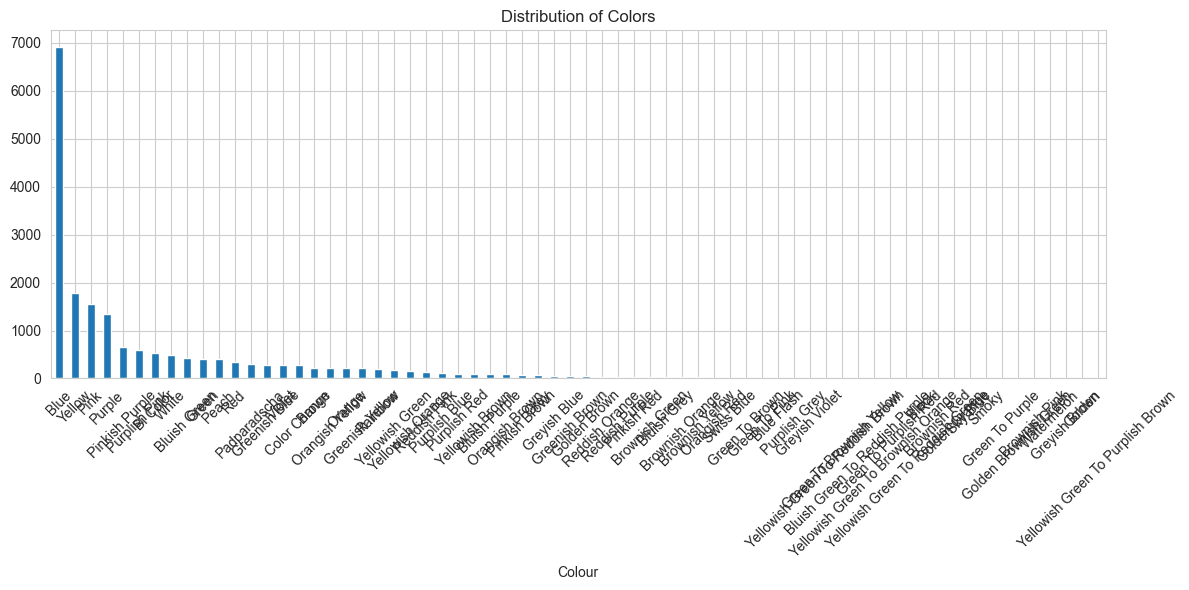

In [33]:
def standardize_color(color):
    """
    Standardize color descriptions to a consistent format
    """
    if pd.isna(color):
        return "Unknown"
    
    color = str(color).strip().title()
    
    # Mapping of variations to standard colors
    color_mapping = {
        # Blue variations
        'Medium Blue': 'Blue',
        'Light Blue': 'Blue',
        'Dark Blue': 'Blue',
        'Royal Blue': 'Blue',
        'Cornflower Blue': 'Blue',
        
        # Pink variations
        'Light Pink': 'Pink',
        'Hot Pink': 'Pink',
        'Rose Pink': 'Pink',
        
        # Yellow variations
        'Golden Yellow': 'Yellow',
        'Light Yellow': 'Yellow',
        'Fancy Yellow': 'Yellow',
        
        # Special colors
        'Padparadscha': 'Padparadscha',
        'Color Change': 'Color Change',
        'Parti Colored': 'Bi Color',
        'Parti-Colored': 'Bi Color',
        'Multi Color': 'Bi Color'
    }
    
    return color_mapping.get(color, color)

# Apply standardization to color columns
if 'Colour' in df.columns:
    df['Colour'] = df['Colour'].apply(standardize_color)
if 'ColourHue' in df.columns:
    df['ColourHue'] = df['ColourHue'].apply(standardize_color)

# Display results
print("Unique colors after standardization:")
if 'Colour' in df.columns:
    print("\nColour column:")
    print(df['Colour'].value_counts())
if 'ColourHue' in df.columns:
    print("\nColourHue column:")
    print(df['ColourHue'].value_counts())

# Visualize distribution
plt.figure(figsize=(12, 6))
if 'Colour' in df.columns:
    df['Colour'].value_counts().plot(kind='bar')
elif 'ColourHue' in df.columns:
    df['ColourHue'].value_counts().plot(kind='bar')
plt.title('Distribution of Colors')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Clean Cut/Shape Values

Standardize cut and shape descriptions:
1. Map variations to standard terminology
2. Handle compound descriptions (e.g., "Mixed Brilliant Oval")
3. Separate cut style from shape where applicable

Unique cut/shape values after standardization:
Cut/Shape
Mixed Brilliant Oval           4976
Mixed Brilliant Cushion        3536
Mixed Brilliant Round          3484
Emerald Cut Emerald Cut        1962
Mixed Brilliant Pear           1790
                               ... 
Radiant Cut Cushion               1
European Cut Emerald Cut          1
Fancy Cut Asscher - Octagon       1
Fancy Brilliant Cushion           1
Asscher Oval                      1
Name: count, Length: 70, dtype: int64


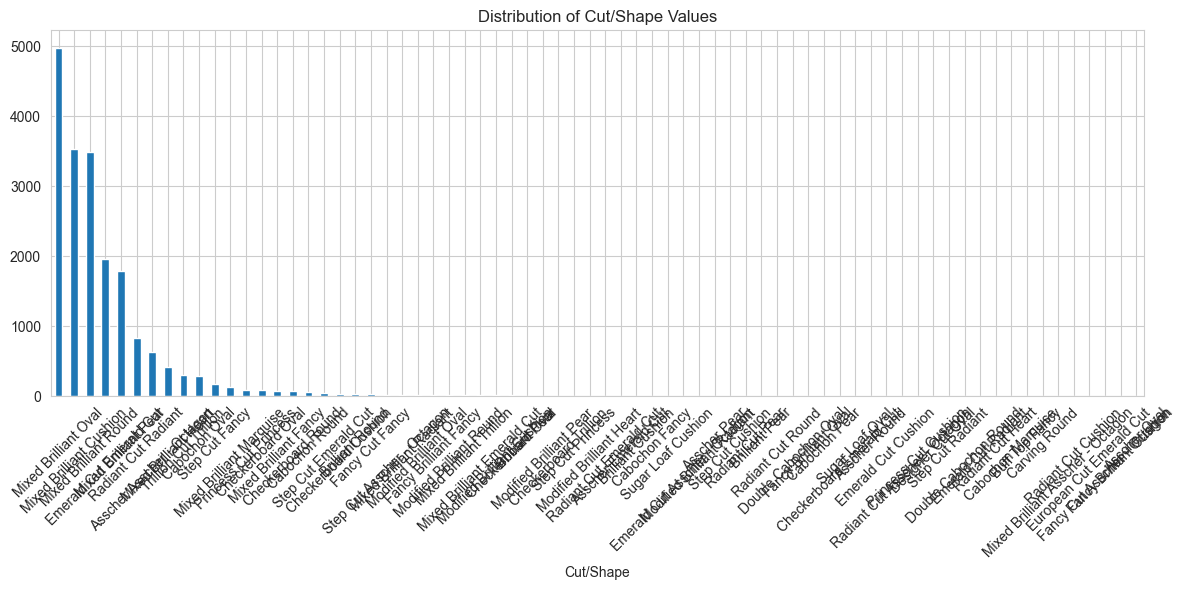

In [34]:
def standardize_cut_shape(cut_shape):
    """
    Standardize cut and shape descriptions to a consistent format
    """
    if pd.isna(cut_shape):
        return "Unknown"
    
    cut_shape = str(cut_shape).strip().title()
    
    # Mapping of variations to standard cuts/shapes
    cut_shape_mapping = {
        # Oval variations
        'Ovl': 'Oval',
        'Oval Mixed': 'Mixed Brilliant Oval',
        'Oval Brilliant': 'Mixed Brilliant Oval',
        
        # Round variations
        'Rnd': 'Round',
        'Round Brilliant': 'Mixed Brilliant Round',
        'Round Mixed': 'Mixed Brilliant Round',
        
        # Cushion variations
        'Cush': 'Cushion',
        'Cushion Mixed': 'Mixed Brilliant Cushion',
        'Cushion Brilliant': 'Mixed Brilliant Cushion',
        
        # Other shapes
        'Pear Shape': 'Pear',
        'Heart Shape': 'Heart',
        'Square': 'Princess',
        'Emerald Cut': 'Emerald',
        'Oct': 'Octagon',
        'Marquise': 'Marquise'
    }
    
    return cut_shape_mapping.get(cut_shape, cut_shape)

# Apply standardization
df['Cut/Shape'] = df['Cut/Shape'].apply(standardize_cut_shape)

# Display results
print("Unique cut/shape values after standardization:")
print(df['Cut/Shape'].value_counts())

# Visualize distribution
plt.figure(figsize=(12, 6))
df['Cut/Shape'].value_counts().plot(kind='bar')
plt.title('Distribution of Cut/Shape Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Standardize Treatment Labels

Create consistent treatment categories:
1. Map variations to standard terms
2. Handle multiple treatments
3. Create binary flags for common treatments

Unique treatment values after standardization:
Treatments
Heat Treated             9549
No Enhancement           9488
Vapor-Infused Coating     118
Beryllium Diffused         39
Irradiation                31
Not Specified               4
Name: count, dtype: int64


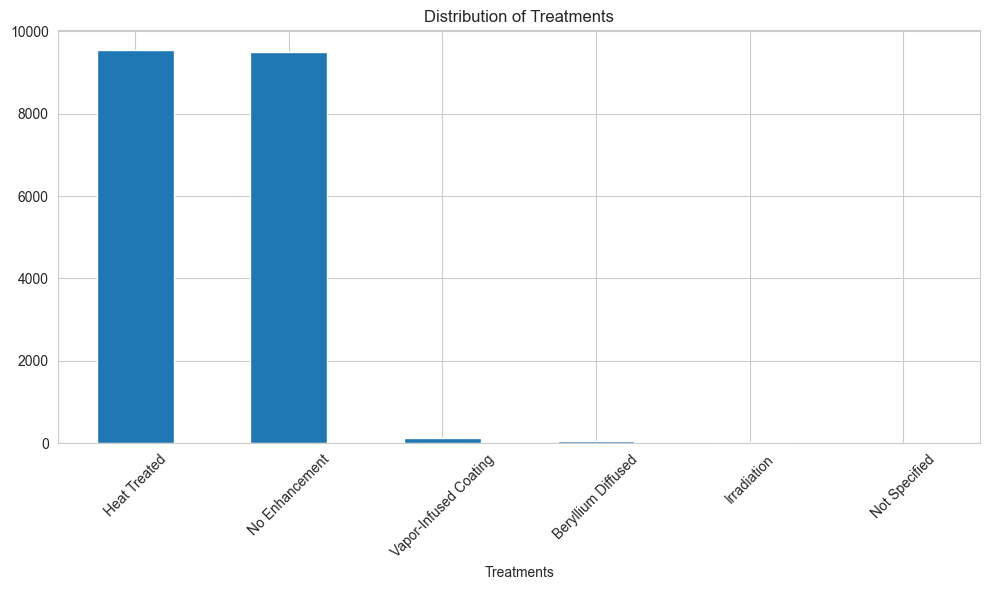

In [35]:
def standardize_treatment(treatment):
    """
    Standardize treatment descriptions to a consistent format
    """
    if pd.isna(treatment):
        return "None"
    
    treatment = str(treatment).strip().title()
    
    # Mapping of variations to standard treatments
    treatment_mapping = {
        # Heat treatment variations
        'Heated': 'Heat Treated',
        'Heat': 'Heat Treated',
        'Traditional Heat': 'Heat Treated',
        
        # No treatment variations
        'None': 'No Treatment',
        'Natural': 'No Treatment',
        'Untreated': 'No Treatment',
        'Not Treated': 'No Treatment',
        
        # Other treatments
        'Glass Filled': 'Glass Filled',
        'Clarity Enhanced': 'Clarity Enhanced',
        'Be': 'Beryllium Treated',
        'Beryllium': 'Beryllium Treated'
    }
    
    return treatment_mapping.get(treatment, treatment)

# Apply standardization
df['Treatments'] = df['Treatments'].apply(standardize_treatment)

# Display results
print("Unique treatment values after standardization:")
print(df['Treatments'].value_counts())

# Visualize distribution
plt.figure(figsize=(10, 6))
df['Treatments'].value_counts().plot(kind='bar')
plt.title('Distribution of Treatments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Normalize Certification Status

Convert certification information into a consistent format:
1. Create binary certified/uncertified flag
2. Standardize certification authority names
3. Handle multiple certificates

Unique certification status values after standardization:
Certification Status
Yes    19229
Name: count, dtype: int64


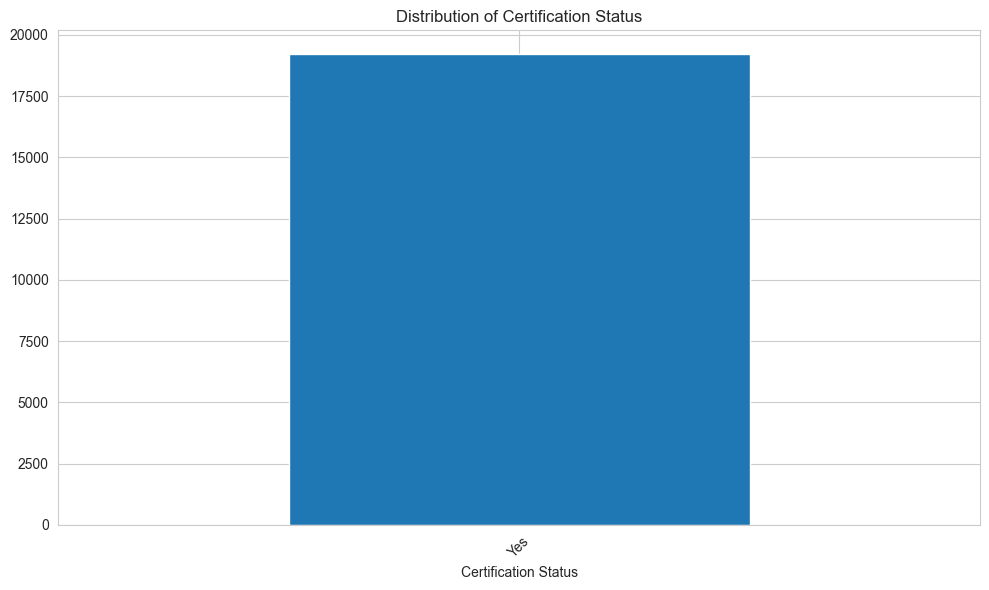

In [36]:
def standardize_certification(cert_status):
    """
    Standardize certification status to Yes/No
    """
    if pd.isna(cert_status):
        return "No"
    
    cert_status = str(cert_status).strip().lower()
    
    # Check if certified
    is_certified = any(word in cert_status for word in ['certified', 'cert', 'certificate'])
    
    return "Yes" if is_certified else "No"

# Apply standardization
df['Certification Status'] = df['Certification Status'].apply(standardize_certification)

# Display results
print("Unique certification status values after standardization:")
print(df['Certification Status'].value_counts())

# Visualize distribution
plt.figure(figsize=(10, 6))
df['Certification Status'].value_counts().plot(kind='bar')
plt.title('Distribution of Certification Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Export Cleaned Dataset

Save the cleaned dataset and create documentation of the standardization rules.

In [ ]:
# Create a data dictionary documenting the standardization rules
data_dictionary = {
    'Gem Type': {
        'description': 'Type of gemstone',
        'standardization_rules': 'Mapped variations to standard names, corrected spellings',
        'unique_values': sorted(df['Gem Type'].unique())
    },
    'Clarity': {
        'description': 'Clarity grade of the gemstone',
        'standardization_rules': 'Mapped to standard grades: VVS, VS, SI, I, Eye Clean',
        'unique_values': sorted(df['Clarity'].unique())
    },
    'Colour': {
        'description': 'Color of the gemstone',
        'standardization_rules': 'Mapped color variations to standard categories',
        'unique_values': sorted(df['Colour'].unique()) if 'Colour' in df.columns else []
    },
    'Cut/Shape': {
        'description': 'Cut and shape of the gemstone',
        'standardization_rules': 'Standardized cut/shape terminology',
        'unique_values': sorted(df['Cut/Shape'].unique())
    },
    'Treatments': {
        'description': 'Treatment methods applied to the gemstone',
        'standardization_rules': 'Mapped to standard treatment categories',
        'unique_values': sorted(df['Treatments'].unique())
    },
    'Certification Status': {
        'description': 'Whether the gem is certified',
        'standardization_rules': 'Converted to Yes/No values',
        'unique_values': sorted(df['Certification Status'].unique())
    }
}

# Save the cleaned dataset with absolute path
output_path = '/Users/helithasri/Personal/Gem Price Prediction System Ratnapura Srilanka/notebooks/data/processed/cleaned_gems.csv'
df.to_csv(output_path, index=False)

# Save the data dictionary with absolute path
dict_path = '/Users/helithasri/Personal/Gem Price Prediction System Ratnapura Srilanka/notebooks/data/processed/data_dictionary.txt'
with open(dict_path, 'w') as f:
    f.write("# Gem Dataset Data Dictionary\n\n")
    for column, info in data_dictionary.items():
        f.write(f"## {column}\n")
        f.write(f"Description: {info['description']}\n")
        f.write(f"Standardization: {info['standardization_rules']}\n")
        f.write("Unique values:\n")
        for value in info['unique_values']:
            f.write(f"- {value}\n")
        f.write("\n")

print(f"Cleaned dataset saved to: {output_path}")
print(f"Data dictionary saved to: {dict_path}")

# Display summary statistics
print("\nSummary of standardization results:")
for column in ['Gem Type', 'Clarity', 'Cut/Shape', 'Treatments', 'Certification Status']:
    print(f"\n{column} value counts:")
    print(df[column].value_counts())

Cleaned dataset saved to: /Users/helithasri/Personal/Gem Price Prediction System Ratnapura Srilanka/notebooks/data/processed/cleaned_gems.csv
Data dictionary saved to: /Users/helithasri/Personal/Gem Price Prediction System Ratnapura Srilanka/notebooks/data/processed/data_dictionary.txt

Summary of standardization results:

Gem Type value counts:
Gem Type
Sapphire                15638
Spinel                    888
Moonstone                 447
Garnet                    437
Zircon                    401
Citrine                   284
Chrysoberyl               259
Amethyst                  165
Topaz                     156
Rhodolite Garnet          129
Tourmaline                105
Aquamarine                 78
Hessonite Garnet           69
Alexandrite                48
Cobalt Spinel              30
Ruby                       29
Almandine Garnet           21
Beryl                      11
Kornerupine                 8
Rubellite Tourmaline        7
Spessartite Garnet          5
Sinhalite    